# Analyze pendulum data
Use this notebook to quickly test whether your pendulum data makes sense!

In [152]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from iminuit import Minuit
from iminuit import cost
from scipy import stats
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [153]:
# Example file location
filenames = ['data_pendulum_example/Matilde.dat', 
             'data_pendulum_example/Amalie_2.dat', 
             'data_pendulum_example/timer_output_Marta_last_take.dat', 
             'data_pendulum_example/giuia.dat', 
             'data_pendulum_example/Adam1.dat'
            ]

## Data reader

In [154]:
# Read in data
def read_data(filename):
    dat = np.genfromtxt(filename, delimiter='\t', names=('n', 't_s'))
    return dat

def weighted_mean(value, error) :
    assert(len(value) == len(error))
    wmean = np.sum((value/(error**2)) / np.sum(1.0/(error**2)))
    wmean_err = error = np.sqrt(1.0/np.sum(1.0/np.square(error)))
    return wmean, wmean_err

## Read and plot the data

C:\Users\mf\AppData\Local\Temp\ipykernel_4420\767463795.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


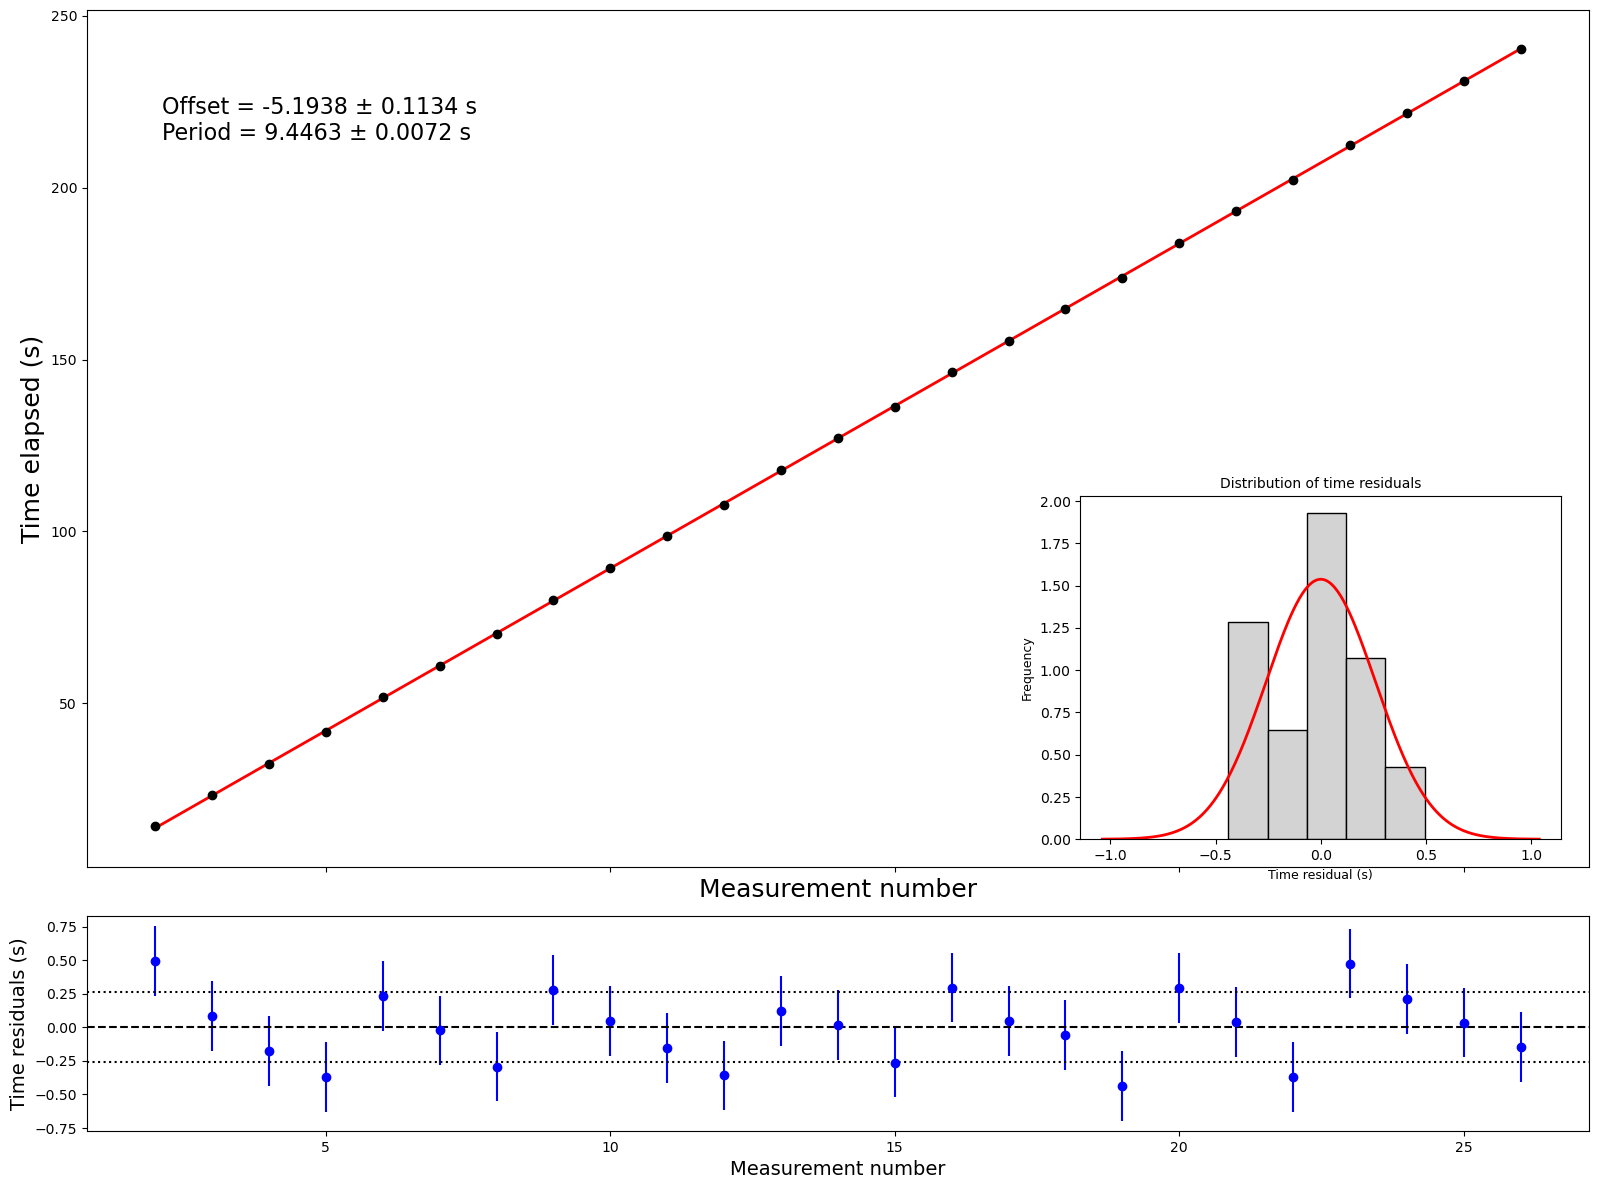

In [155]:
data_example = read_data(filenames[0])
n, t = data_example['n'], data_example['t_s']

sig_t_guess = 0.1     

# Fitting
def lin_fit(x, a, b):
    return a*x+b

cfit = cost.LeastSquares(n, t, sig_t_guess, lin_fit)
mfit = Minuit(cfit, a=0, b=0)
mfit.migrad()

a_fit1 = mfit.values["a"]
b_fit1 = mfit.values["b"]

model = lin_fit(n, a_fit1, b_fit1)
residuals = t - model

mu_t, sigma_t = stats.norm.fit(residuals)

# Redo first plot with new sigma value
cfit = cost.LeastSquares(n, t, sigma_t, lin_fit)

mfit = Minuit(cfit, a=0, b=0)
mfit.migrad()

a_fit2 = mfit.values["a"]
b_fit2 = mfit.values["b"]
ea_fit2 = mfit.errors["a"]
eb_fit2 = mfit.errors["b"]

# Plot
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(16, 12),
                       gridspec_kw={'height_ratios':[4,1]}, sharex=True)

ax0 = ax[0]
ax0.set_xlabel('Measurement number', fontsize=18)
ax0.set_ylabel('Time elapsed (s)', fontsize=18)

ax0.errorbar(n, t, yerr=ea_fit2, color='k', fmt='o', markersize=6)
ax0.plot(n, model, 'r-', linewidth=2)

# Inset gaussian 
inset = inset_axes(ax0, width="32%", height="40%", loc='lower right',
                   borderpad=2)

# Histogram
inset.hist(residuals, bins=5, density=True, edgecolor="black",
           color="lightgray")

# Gaussian
x = np.linspace(mu_t - 4*sigma_t, mu_t + 4*sigma_t, 300)
gauss = stats.norm.pdf(x, mu_t, sigma_t)
inset.plot(x, gauss, 'r-', linewidth=2)

inset.set_title("Distribution of time residuals", fontsize=10)
inset.set_xlabel("Time residual (s)", fontsize=9)
inset.set_ylabel("Frequency", fontsize=9)

# Plot residuals
ax1 = ax[1]
ax1.errorbar(n, residuals, yerr=sigma_t, fmt='o', color='b')
ax1.axhline(0, color='k', linestyle='--')
ax1.axhline(+sigma_t, color='k', linestyle=':')
ax1.axhline(-sigma_t, color='k', linestyle=':')

ax1.set_ylabel("Time residuals (s)", fontsize=14)
ax1.set_xlabel("Measurement number", fontsize=14)

# Set text
ax0.text(
    0.05, 0.90,
    f"Offset = {b_fit2:.4f} ± {eb_fit2:.4f} s\n"
    f"Period = {a_fit2:.4f} ± {ea_fit2:.4f} s\n",
    transform=ax0.transAxes,
    fontsize=16,
    va='top'
)

plt.tight_layout()
plt.show()

T1 = a_fit2
eT1 = ea_fit2


C:\Users\mf\AppData\Local\Temp\ipykernel_4420\3774718111.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


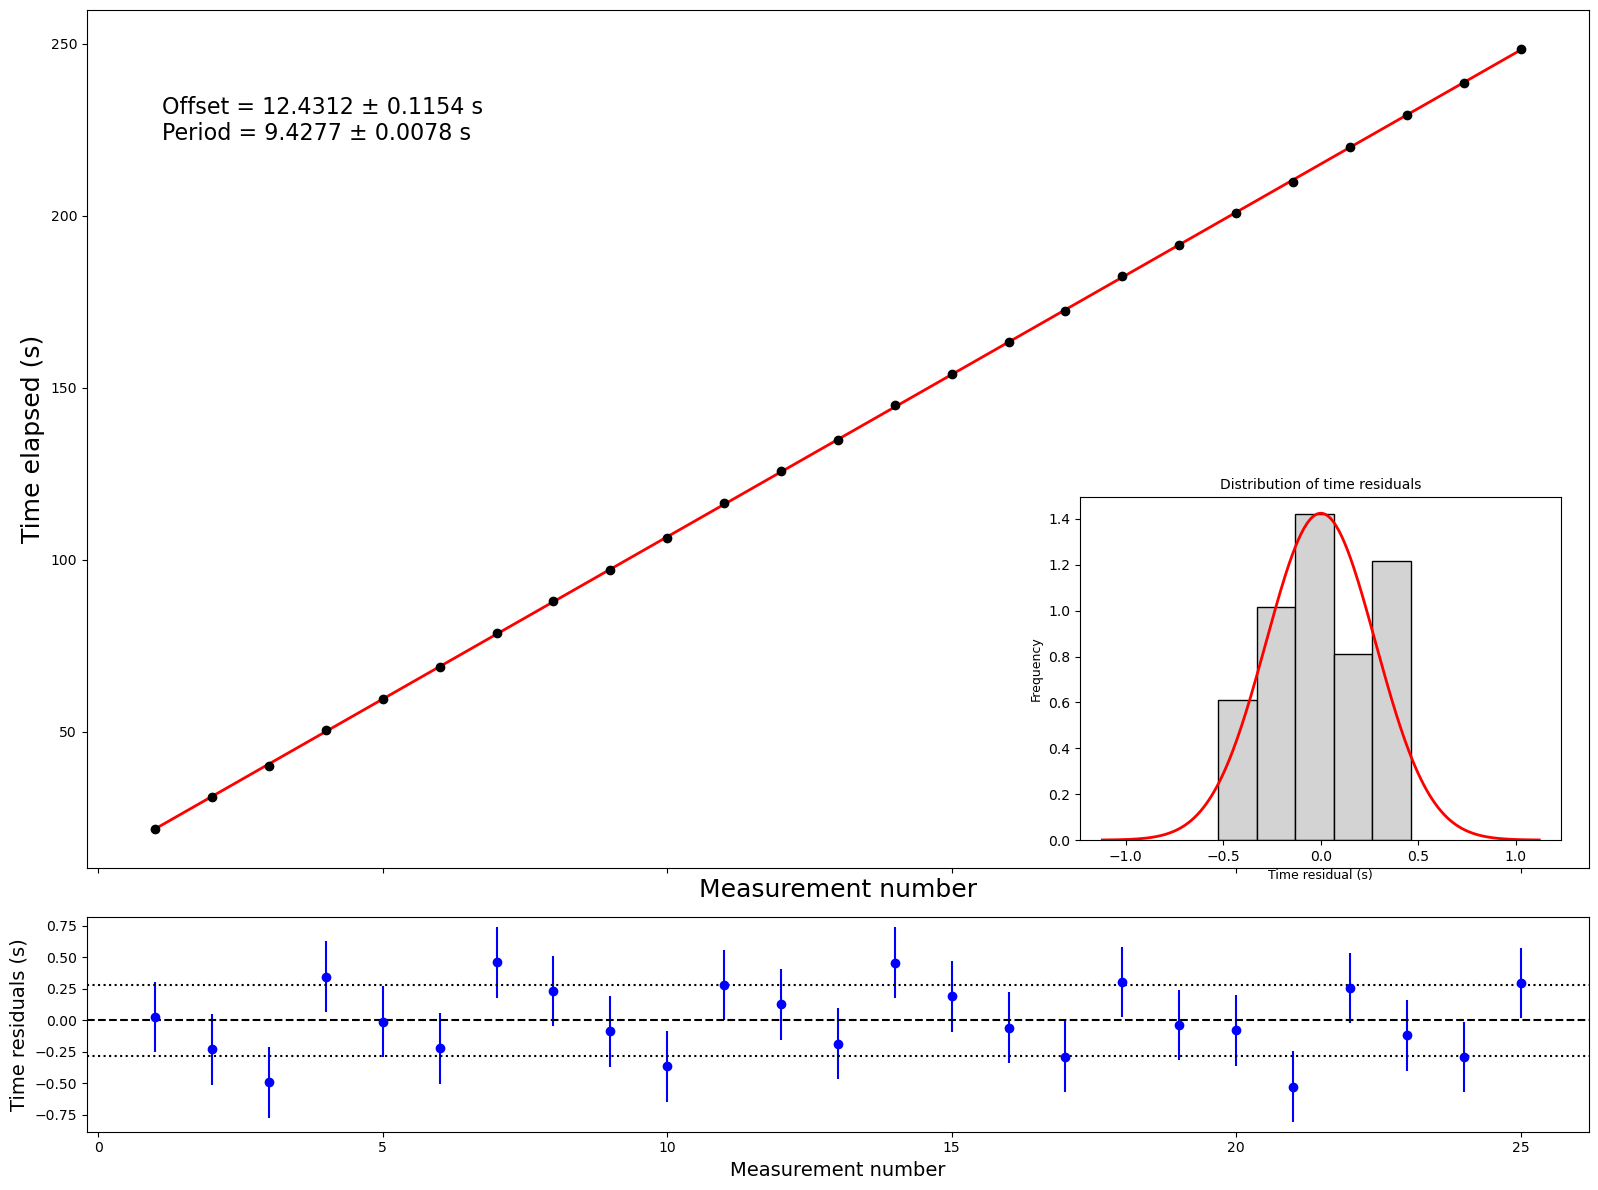

In [156]:
data_example = read_data(filenames[1])
n, t = data_example['n'], data_example['t_s']

sig_t_guess = 0.01     

# Fitting
def lin_fit(x, a, b):
    return a*x+b

cfit = cost.LeastSquares(n, t, sig_t_guess, lin_fit)
mfit = Minuit(cfit, a=0, b=0)
mfit.migrad()

a_fit1 = mfit.values["a"]
b_fit1 = mfit.values["b"]

model = lin_fit(n, a_fit1, b_fit1)
residuals = t - model

mu_t, sigma_t = stats.norm.fit(residuals)

# Redo first plot with new sigma value
cfit = cost.LeastSquares(n, t, sigma_t, lin_fit)

mfit = Minuit(cfit, a=0, b=0)
mfit.migrad()

a_fit2 = mfit.values["a"]
b_fit2 = mfit.values["b"]
ea_fit2 = mfit.errors["a"]
eb_fit2 = mfit.errors["b"]

# Plot
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(16, 12),
                       gridspec_kw={'height_ratios':[4,1]}, sharex=True)

ax0 = ax[0]
ax0.set_xlabel('Measurement number', fontsize=18)
ax0.set_ylabel('Time elapsed (s)', fontsize=18)

ax0.errorbar(n, t, yerr=ea_fit2, color='k', fmt='o', markersize=6)
ax0.plot(n, model, 'r-', linewidth=2)

# Inset gaussian 
inset = inset_axes(ax0, width="32%", height="40%", loc='lower right',
                   borderpad=2)

# Histogram
inset.hist(residuals, bins=5, density=True, edgecolor="black",
           color="lightgray")

# Gaussian
x = np.linspace(mu_t - 4*sigma_t, mu_t + 4*sigma_t, 300)
gauss = stats.norm.pdf(x, mu_t, sigma_t)
inset.plot(x, gauss, 'r-', linewidth=2)

inset.set_title("Distribution of time residuals", fontsize=10)
inset.set_xlabel("Time residual (s)", fontsize=9)
inset.set_ylabel("Frequency", fontsize=9)

# Plot residuals
ax1 = ax[1]
ax1.errorbar(n, residuals, yerr=sigma_t, fmt='o', color='b')
ax1.axhline(0, color='k', linestyle='--')
ax1.axhline(+sigma_t, color='k', linestyle=':')
ax1.axhline(-sigma_t, color='k', linestyle=':')

ax1.set_ylabel("Time residuals (s)", fontsize=14)
ax1.set_xlabel("Measurement number", fontsize=14)

# Set text
ax0.text(
    0.05, 0.90,
    f"Offset = {b_fit2:.4f} ± {eb_fit2:.4f} s\n"
    f"Period = {a_fit2:.4f} ± {ea_fit2:.4f} s\n",
    transform=ax0.transAxes,
    fontsize=16,
    va='top'
)

plt.tight_layout()
plt.show()

T2 = a_fit2
eT2 = ea_fit2


C:\Users\mf\AppData\Local\Temp\ipykernel_4420\4015203941.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


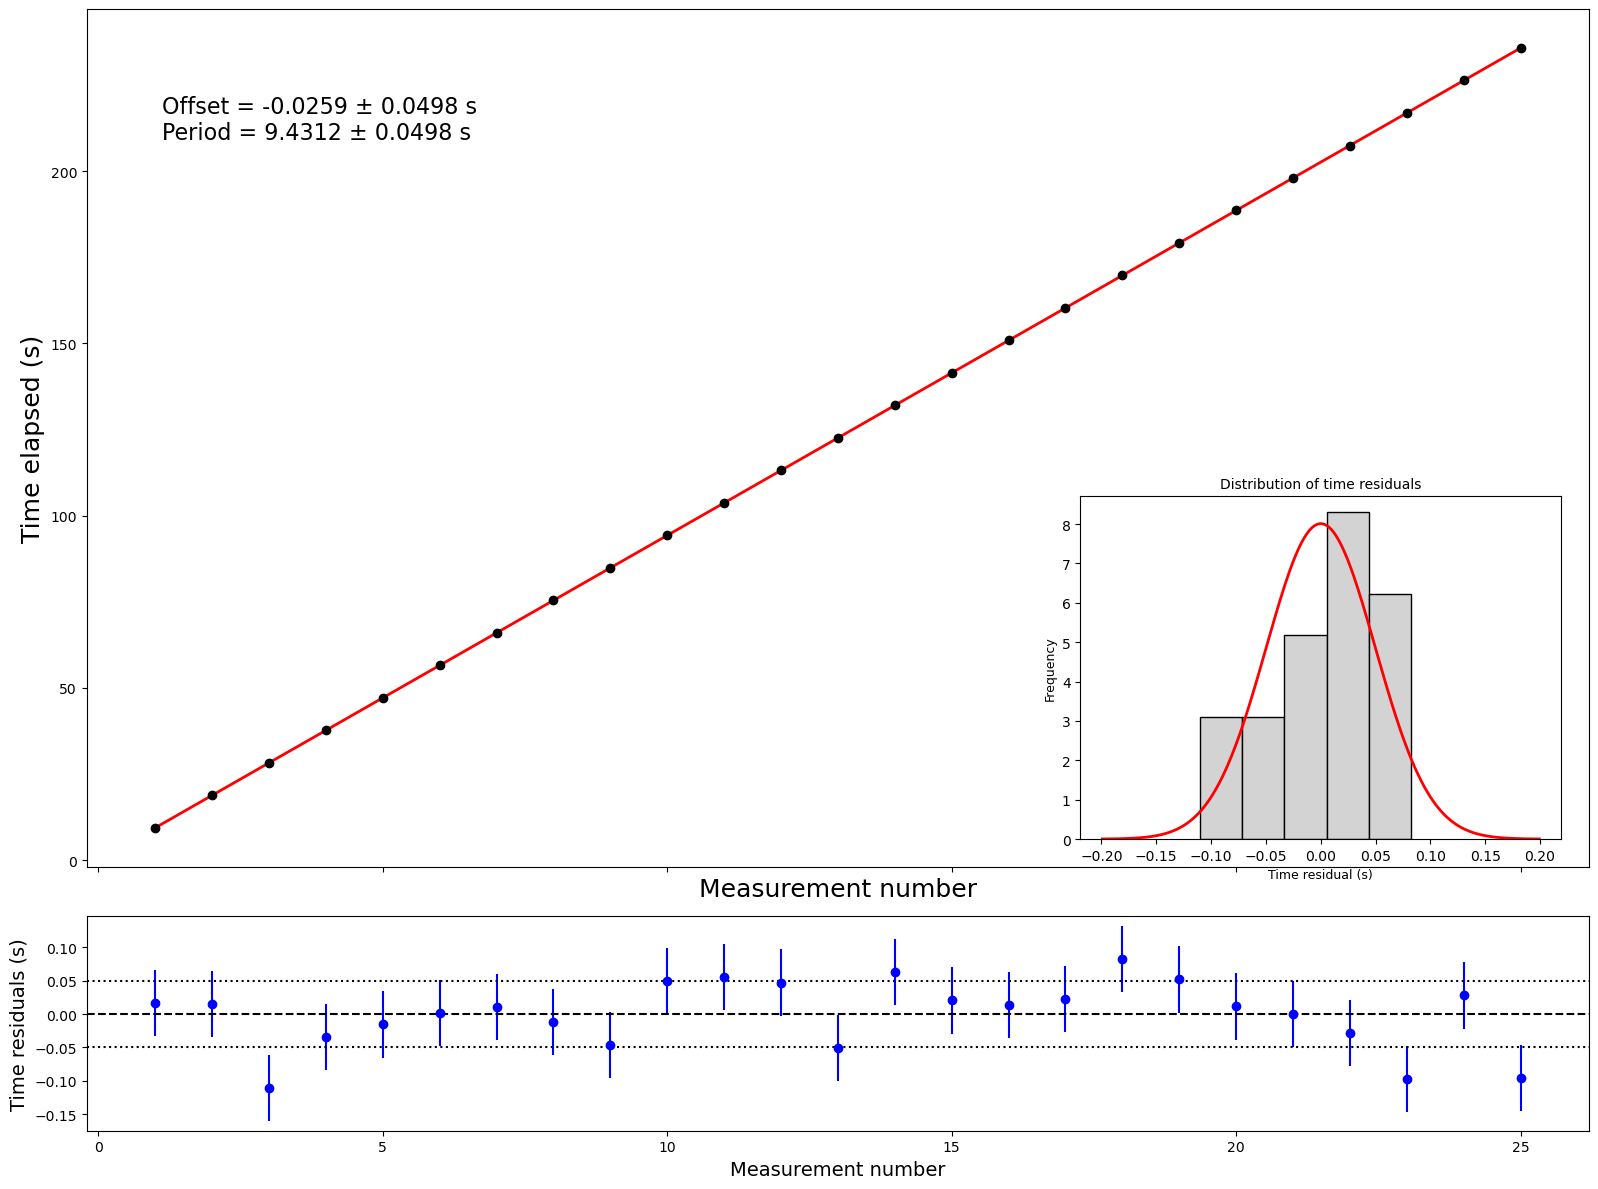

In [157]:
data_example = read_data(filenames[2])
n, t = data_example['n'], data_example['t_s']

sig_t_guess = 0.1     

# Fitting
def lin_fit(x, a, b):
    return a*x+b

cfit = cost.LeastSquares(n, t, sig_t_guess, lin_fit)
mfit = Minuit(cfit, a=0, b=0)
mfit.migrad()

a_fit1 = mfit.values["a"]
b_fit1 = mfit.values["b"]

model = lin_fit(n, a_fit1, b_fit1)
residuals = t - model

mu_t, sigma_t = stats.norm.fit(residuals)

# Redo first plot with new sigma value
cfit = cost.LeastSquares(n, t, sigma_t, lin_fit)

mfit = Minuit(cfit, a=0, b=0)
mfit.migrad()

a_fit2 = mfit.values["a"]
b_fit2 = mfit.values["b"]
ea_fit2 = mfit.errors["a"]
eb_fit2 = mfit.errors["b"]

# Plot
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(16, 12),
                       gridspec_kw={'height_ratios':[4,1]}, sharex=True)

ax0 = ax[0]
ax0.set_xlabel('Measurement number', fontsize=18)
ax0.set_ylabel('Time elapsed (s)', fontsize=18)

ax0.errorbar(n, t, yerr=ea_fit2, color='k', fmt='o', markersize=6)
ax0.plot(n, model, 'r-', linewidth=2)

# Inset gaussian 
inset = inset_axes(ax0, width="32%", height="40%", loc='lower right',
                   borderpad=2)

# Histogram
inset.hist(residuals, bins=5, density=True, edgecolor="black",
           color="lightgray")

# Gaussian
x = np.linspace(mu_t - 4*sigma_t, mu_t + 4*sigma_t, 300)
gauss = stats.norm.pdf(x, mu_t, sigma_t)
inset.plot(x, gauss, 'r-', linewidth=2)

inset.set_title("Distribution of time residuals", fontsize=10)
inset.set_xlabel("Time residual (s)", fontsize=9)
inset.set_ylabel("Frequency", fontsize=9)

# Plot residuals
ax1 = ax[1]
ax1.errorbar(n, residuals, yerr=sigma_t, fmt='o', color='b')
ax1.axhline(0, color='k', linestyle='--')
ax1.axhline(+sigma_t, color='k', linestyle=':')
ax1.axhline(-sigma_t, color='k', linestyle=':')

ax1.set_ylabel("Time residuals (s)", fontsize=14)
ax1.set_xlabel("Measurement number", fontsize=14)

# Set text
ax0.text(
    0.05, 0.90,
    f"Offset = {b_fit2:.4f} ± {sigma_t:.4f} s\n"
    f"Period = {a_fit2:.4f} ± {sigma_t:.4f} s\n",
    transform=ax0.transAxes,
    fontsize=16,
    va='top'
)

plt.tight_layout()
plt.show()

T3 = a_fit2
eT3 = ea_fit2


C:\Users\mf\AppData\Local\Temp\ipykernel_4420\208686258.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


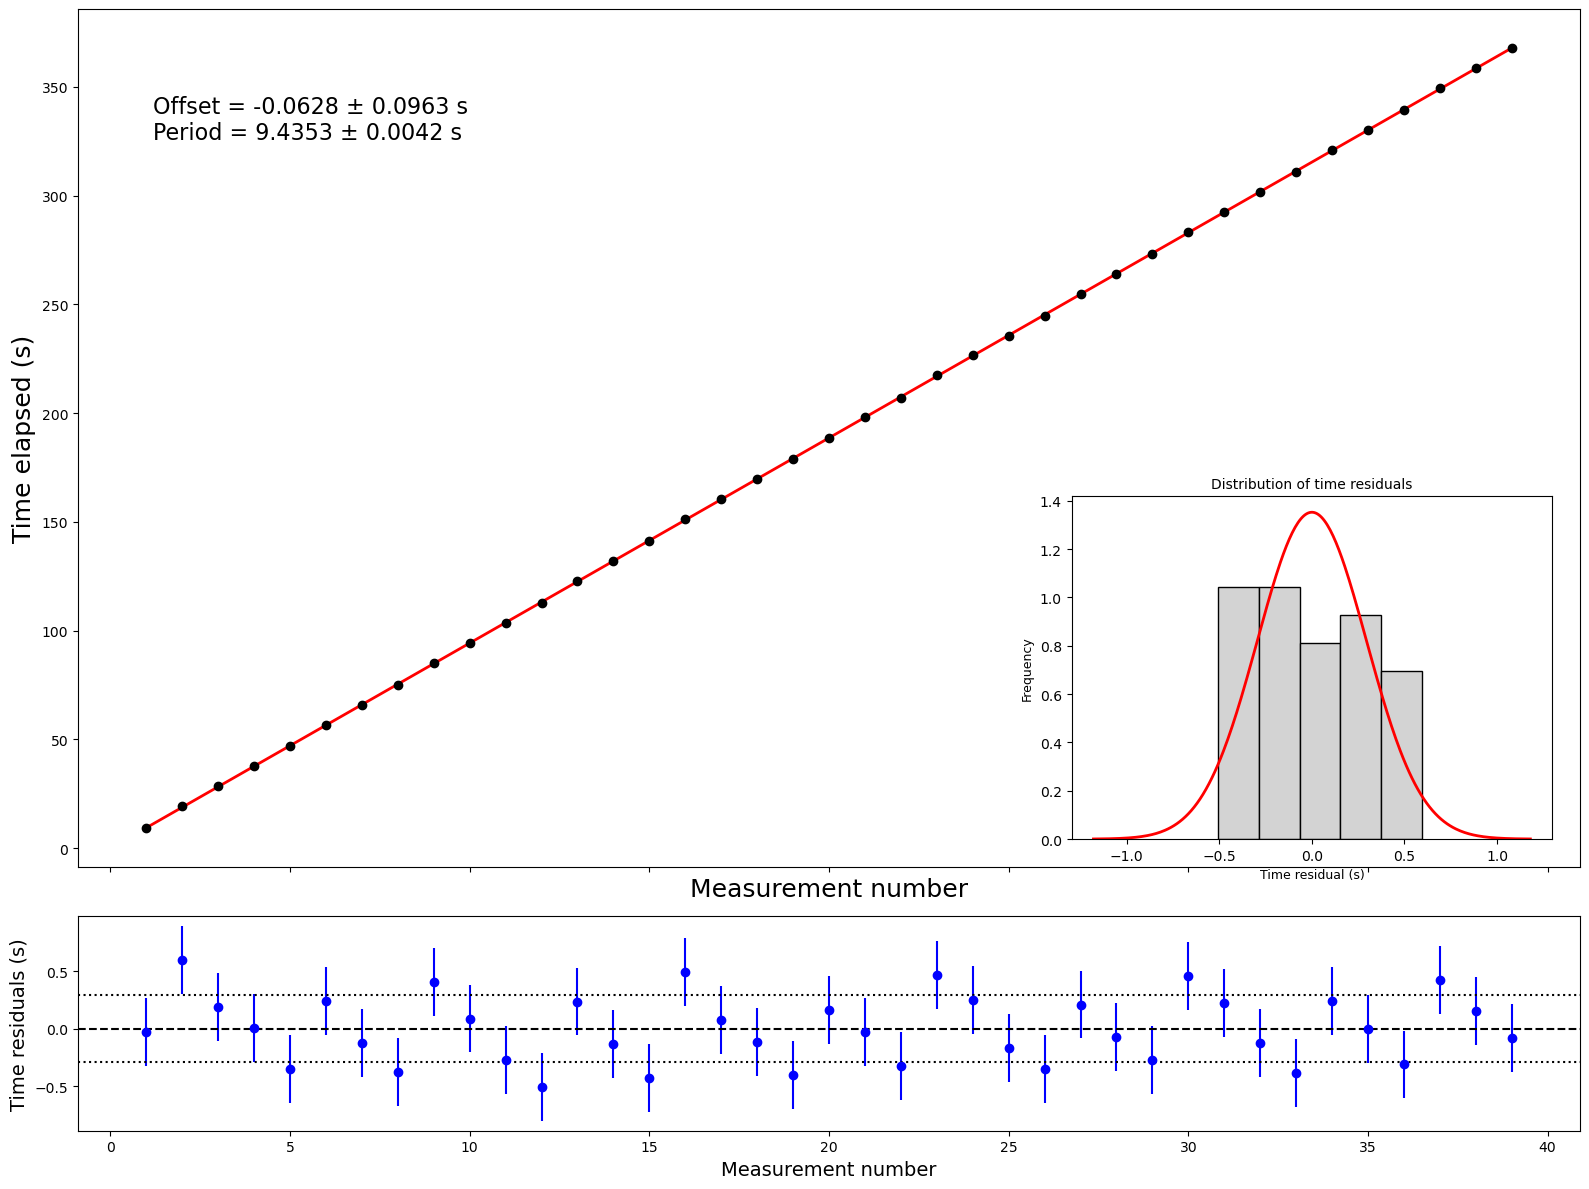

In [158]:
data_example = read_data(filenames[3])
n, t = data_example['n'], data_example['t_s']

sig_t_guess = 0.1     

# Fitting
def lin_fit(x, a, b):
    return a*x+b

cfit = cost.LeastSquares(n, t, sig_t_guess, lin_fit)
mfit = Minuit(cfit, a=0, b=0)
mfit.migrad()

a_fit1 = mfit.values["a"]
b_fit1 = mfit.values["b"]

model = lin_fit(n, a_fit1, b_fit1)
residuals = t - model

mu_t, sigma_t = stats.norm.fit(residuals)

# Redo first plot with new sigma value
cfit = cost.LeastSquares(n, t, sigma_t, lin_fit)

mfit = Minuit(cfit, a=0, b=0)
mfit.migrad()

a_fit2 = mfit.values["a"]
b_fit2 = mfit.values["b"]
ea_fit2 = mfit.errors["a"]
eb_fit2 = mfit.errors["b"]

# Plot
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(16, 12),
                       gridspec_kw={'height_ratios':[4,1]}, sharex=True)

ax0 = ax[0]
ax0.set_xlabel('Measurement number', fontsize=18)
ax0.set_ylabel('Time elapsed (s)', fontsize=18)

ax0.errorbar(n, t, yerr=ea_fit2, color='k', fmt='o', markersize=6)
ax0.plot(n, model, 'r-', linewidth=2)

# Inset gaussian 
inset = inset_axes(ax0, width="32%", height="40%", loc='lower right',
                   borderpad=2)

# Histogram
inset.hist(residuals, bins=5, density=True, edgecolor="black",
           color="lightgray")

# Gaussian
x = np.linspace(mu_t - 4*sigma_t, mu_t + 4*sigma_t, 300)
gauss = stats.norm.pdf(x, mu_t, sigma_t)
inset.plot(x, gauss, 'r-', linewidth=2)

inset.set_title("Distribution of time residuals", fontsize=10)
inset.set_xlabel("Time residual (s)", fontsize=9)
inset.set_ylabel("Frequency", fontsize=9)

# Plot residuals
ax1 = ax[1]
ax1.errorbar(n, residuals, yerr=sigma_t, fmt='o', color='b')
ax1.axhline(0, color='k', linestyle='--')
ax1.axhline(+sigma_t, color='k', linestyle=':')
ax1.axhline(-sigma_t, color='k', linestyle=':')

ax1.set_ylabel("Time residuals (s)", fontsize=14)
ax1.set_xlabel("Measurement number", fontsize=14)

# Set text
ax0.text(
    0.05, 0.90,
    f"Offset = {b_fit2:.4f} ± {eb_fit2:.4f} s\n"
    f"Period = {a_fit2:.4f} ± {ea_fit2:.4f} s\n",
    transform=ax0.transAxes,
    fontsize=16,
    va='top'
)

plt.tight_layout()
plt.show()

T4 = a_fit2
eT4 = ea_fit2

C:\Users\mf\AppData\Local\Temp\ipykernel_4420\28110286.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


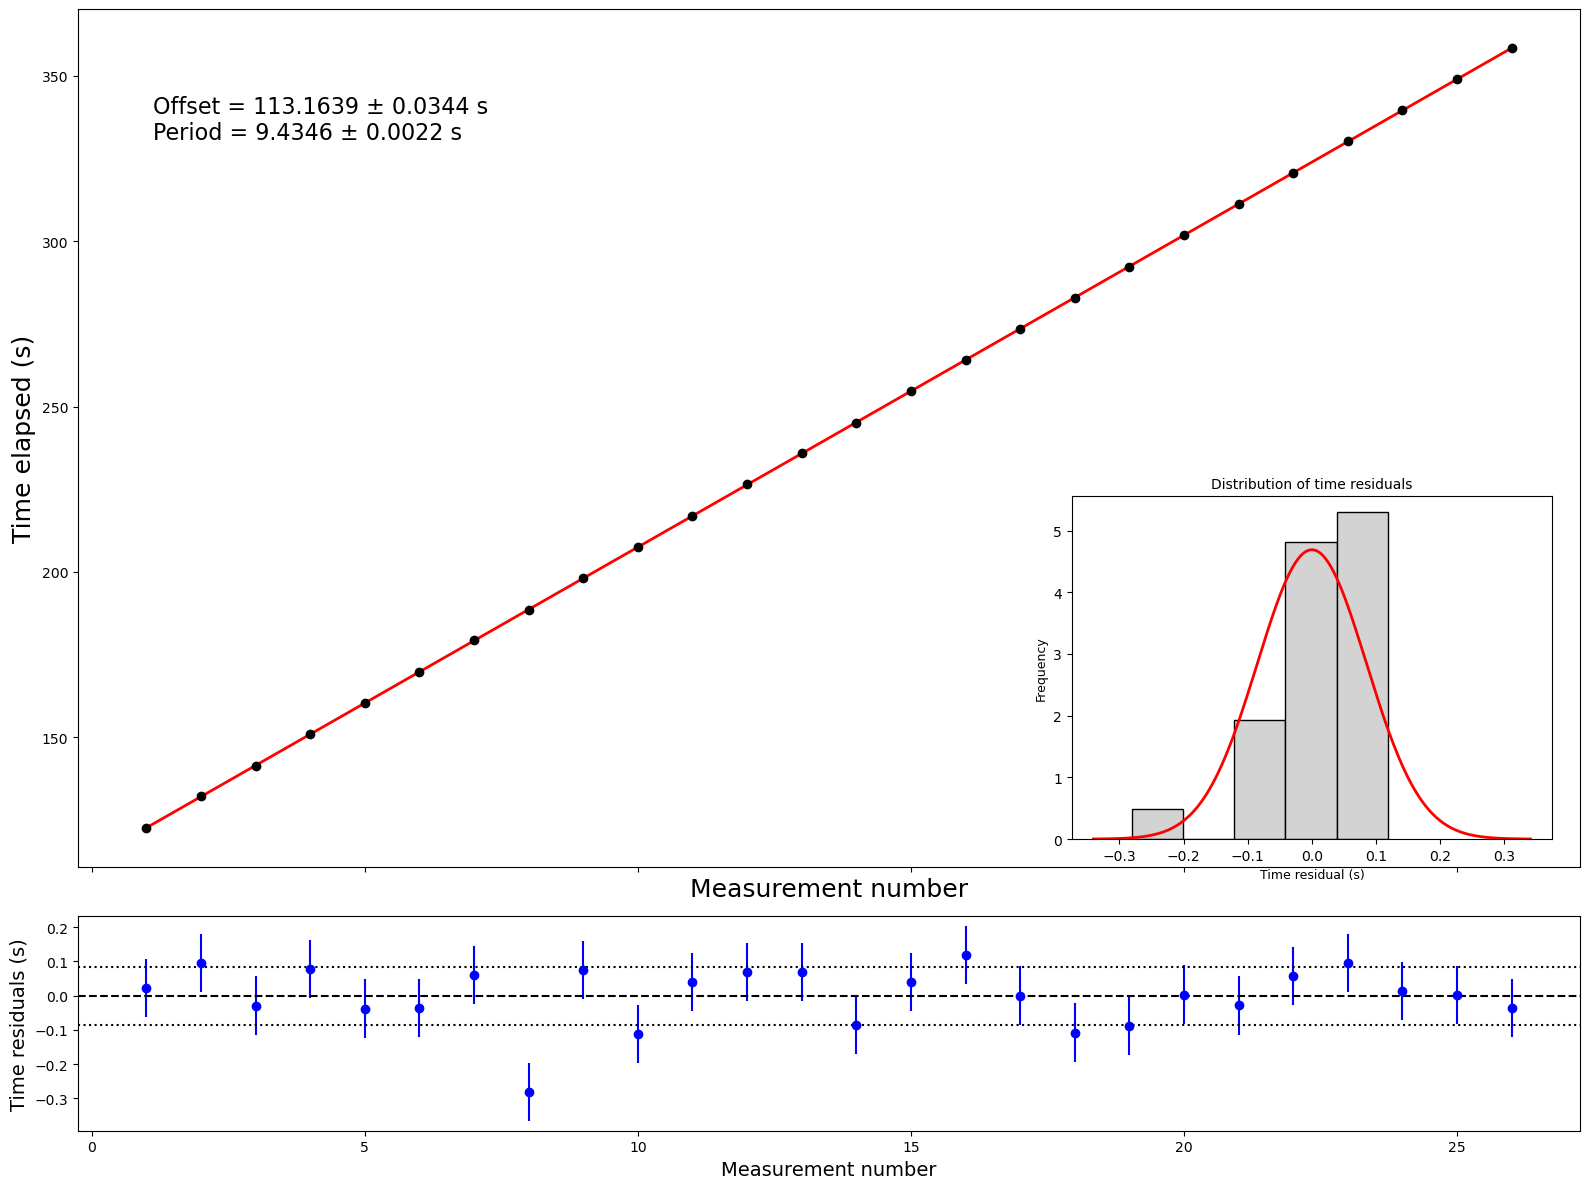

In [159]:
data_example = read_data(filenames[4])
n, t = data_example['n'], data_example['t_s']

sig_t_guess = 0.1     

# Fitting
def lin_fit(x, a, b):
    return a*x+b

cfit = cost.LeastSquares(n, t, sig_t_guess, lin_fit)
mfit = Minuit(cfit, a=0, b=0)
mfit.migrad()

a_fit1 = mfit.values["a"]
b_fit1 = mfit.values["b"]

model = lin_fit(n, a_fit1, b_fit1)
residuals = t - model

mu_t, sigma_t = stats.norm.fit(residuals)

# Redo first plot with new sigma value
cfit = cost.LeastSquares(n, t, sigma_t, lin_fit)

mfit = Minuit(cfit, a=0, b=0)
mfit.migrad()

a_fit2 = mfit.values["a"]
b_fit2 = mfit.values["b"]
ea_fit2 = mfit.errors["a"]
eb_fit2 = mfit.errors["b"]

# Plot
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(16, 12),
                       gridspec_kw={'height_ratios':[4,1]}, sharex=True)

ax0 = ax[0]
ax0.set_xlabel('Measurement number', fontsize=18)
ax0.set_ylabel('Time elapsed (s)', fontsize=18)

ax0.errorbar(n, t, yerr=ea_fit2, color='k', fmt='o', markersize=6)
ax0.plot(n, model, 'r-', linewidth=2)

# Inset gaussian 
inset = inset_axes(ax0, width="32%", height="40%", loc='lower right',
                   borderpad=2)

# Histogram
inset.hist(residuals, bins=5, density=True, edgecolor="black",
           color="lightgray")

# Gaussian
x = np.linspace(mu_t - 4*sigma_t, mu_t + 4*sigma_t, 300)
gauss = stats.norm.pdf(x, mu_t, sigma_t)
inset.plot(x, gauss, 'r-', linewidth=2)

inset.set_title("Distribution of time residuals", fontsize=10)
inset.set_xlabel("Time residual (s)", fontsize=9)
inset.set_ylabel("Frequency", fontsize=9)

# Plot residuals
ax1 = ax[1]
ax1.errorbar(n, residuals, yerr=sigma_t, fmt='o', color='b')
ax1.axhline(0, color='k', linestyle='--')
ax1.axhline(+sigma_t, color='k', linestyle=':')
ax1.axhline(-sigma_t, color='k', linestyle=':')

ax1.set_ylabel("Time residuals (s)", fontsize=14)
ax1.set_xlabel("Measurement number", fontsize=14)

# Set text
ax0.text(
    0.05, 0.90,
    f"Offset = {b_fit2:.4f} ± {eb_fit2:.4f} s\n"
    f"Period = {a_fit2:.4f} ± {ea_fit2:.4f} s\n",
    transform=ax0.transAxes,
    fontsize=16,
    va='top'
)

plt.tight_layout()
plt.show()

T5 = a_fit2
eT5 = ea_fit2

In [173]:
L_t_s = np.array([T1, T2, T3, T4, T5])
eL_t_s = np.array([eT1, eT2, eT3, eT4, eT5])

mean_t_s, err_t_s = weighted_mean(L_t_s, eL_t_s)

#Chi2 fit
from scipy.stats import chi2

chi2_T = np.sum(((L_t_s - mean_t_s) / eL_t_s)**2)
ndof_T = len(L_t_s) - 1
p_T = chi2.sf(chi2_T, ndof_T)

print(f'Weighted mean of period: {mean_t_s} +- {err_t_s} s. \n   Prob(Chi2={chi2_T:.3f}, N_dof={ndof_T}) = {p_T:.4f}\n')


Weighted mean of period: 9.432587947321556 +- 0.0011052694017655812 s. 
   Prob(Chi2=6.316, N_dof=4) = 0.1768



# Length

In [ ]:
L_pendul_m = np.array([25, 25, 25, 24.1, 24.9])/1000
eL_pendul_m = np.array([0.5, 0.5, 0.5, 0.5, 0.5])/1000

L_floor_pendul_m = np.array([56.0, 55.9, 55.9, 56.5, 55.6])/1000
eL_floor_pendul_m = np.array([0.5, 0.5, 0.5, 0.5, 0.5])/1000

L_tape_m = np.array([22.099, 22.101, 22.099, 22.102, 22.102])
eL_tape_m = np.array([0.001, 0.001, 0.001, 0.005, 0.002])

L_laser_m = np.array([22.15, 22.151, 22.152, 22.151, 22.145])
eL_laser_m = np.array([0.01, 0.01, 0.01, 0.01, 0.01])/10

# Corrections for pendulum meassurements

L_pendul_masspoint_m = L_pendul_m/2  # Mass point is half of the pendulum
eL_pendul_masspoint_m = eL_pendul_m/2

L_tape_m += L_pendul_masspoint_m # Tape is tape + half pendulum
eL_tape_m = np.sqrt(eL_tape_m**2 + eL_pendul_masspoint_m**2)

L_laser_m -= L_floor_pendul_m - L_pendul_masspoint_m # Laser is laser minus floor + half pendulum
eL_laser_m = np.sqrt(eL_laser_m**2 + eL_floor_pendul_m**2 + eL_pendul_masspoint_m**2)

mean_L_tape_m, err_L_tape_m = weighted_mean(L_tape_m, eL_tape_m)
mean_L_laser_m, err_L_laser_m = weighted_mean(L_laser_m, eL_laser_m)

List_means = np.array([mean_L_laser_m, mean_L_tape_m])
List_errors = np.array([err_L_laser_m, err_L_tape_m])

mean_combinedL_m, err_combinedL_m = weighted_mean(List_means, List_errors)

# Chi square fit

chi2_tape = np.sum(((L_tape_m - mean_L_tape_m) / eL_tape_m)**2)
ndof_tape = len(L_tape_m) - 1
p_tape = chi2.sf(chi2_tape, ndof_tape)

chi2_laser = np.sum(((L_laser_m - mean_L_laser_m) / eL_laser_m)**2)
ndof_laser = len(L_laser_m) - 1
p_laser = chi2.sf(chi2_laser, ndof_laser)

chi2_L = np.sum(((List_means - mean_combinedL_m) / List_errors)**2)
ndof_L = len(List_means) - 1
p_L = chi2.sf(chi2_L, ndof_L)

print(f"\nMean of L measured with tape: {mean_L_tape_m} +- {err_L_tape_m} m. \n   Prob(Chi2={chi2_tape:.3f}, N_dof={ndof_tape}) = {p_tape:.4f}\n")
print(f"Mean of L measured with laser: {mean_L_laser_m} +- {err_L_laser_m} m. \n   Prob(Chi2={chi2_laser:.3f}, N_dof={ndof_laser}) = {p_laser:.4f}\n")
print(f"Mean of combined L: {mean_combinedL_m} +- {err_combinedL_m} m. \n   Prob(Chi2={chi2_L:.3f}, N_dof={ndof_L}) = {p_L:.4f}")


Mean of L measured with tape: 22.112371580524172 +- 0.0005670859506075976 m. 
   Prob(Chi2=3.804, N_dof=4) = 0.4332

Mean of L measured with laser: 22.106219999999997 +- 0.0005123475382979799 m. 
   Prob(Chi2=20.459, N_dof=4) = 0.0004

Mean of combined L: 22.10898464180506 +- 0.0003801674823156949 m. 
   Prob(Chi2=64.788, N_dof=1) = 0.0000


# Estimating G

In [162]:
def compute_G(L, eL, T, eT):
    G = L * (2*np.pi/T)**2
    L_impact = ((2*np.pi/T)**2 * eL)**2
    T_impact = ((2*G/T) * eT)**2
    eG = np.sqrt(L_impact+T_impact)

    return G, eG, L_impact, T_impact

L = mean_combinedL_m
eL = err_combinedL_m
T = mean_t_s
eT = err_t_s

G, eG, L_impact, T_impact = compute_G(L, eL, T, eT)

print(f'G = {G} +- {eG}')
print(f'L_impact = {L_impact}, T_impact = {T_impact}')

G = 9.8099503289361 +- 0.002305154293446447
L_impact = 2.8454172114366246e-08, T_impact = 5.2852821444802216e-06
